In [3]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from textblob import Word
from wordcloud import WordCloud
from nltk.stem import WordNetLemmatizer
import plotly.express as px

from nltk.tokenize import word_tokenize
import re
from collections import Counter

import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

## Carga de datos

In [ ]:
# Cargar los archivos CSV
df_true = pd.read_csv('data/True.csv')
df_fake = pd.read_csv('data/Fake.csv')

# Agregar la columna 'output' con el nombre del archivo
df_true['output'] = 'True'
df_fake['output'] = 'Fake'

# Unir ambos DataFrames
df = pd.concat([df_true, df_fake], ignore_index=True)

# Mostrar las primeras filas del dataframe combinado
df.head()


,title,text,subject,date,output
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",True
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",True
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",True
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",True
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",True


In [ ]:
# Number of duplicate rows
df.duplicated().sum()

209

In [5]:
# Eliminación de duplicados
df_clean = df.drop_duplicates()

In [ ]:
df_clean.duplicated().sum()

0

In [ ]:
df_clean

,title,text,subject,date,output
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",True
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",True
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",True
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",True
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",True
...,...,...,...,...,...
44893,McPain: John McCain Furious That Iran Treated ...,21st Century Wire says As 21WIRE reported earl...,Middle-east,"January 16, 2016",Fake
44894,JUSTICE? Yahoo Settles E-mail Privacy Class-ac...,21st Century Wire says It s a familiar theme. ...,Middle-east,"January 16, 2016",Fake
44895,Sunnistan: US and Allied ‘Safe Zone’ Plan to T...,Patrick Henningsen 21st Century WireRemember ...,Middle-east,"January 15, 2016",Fake
44896,How to Blow $700 Million: Al Jazeera America F...,21st Century Wire says Al Jazeera America will...,Middle-east,"January 14, 2016",Fake


In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44689 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44689 non-null  object
 1   text     44689 non-null  object
 2   subject  44689 non-null  object
 3   date     44689 non-null  object
 4   output   44689 non-null  object
dtypes: object(5)
memory usage: 2.0+ MB


## Balanceo de clases

In [ ]:
def check_class_imbalance(data, column_name):
    # Calculate the frequency of each class
    class_counts = data[column_name].value_counts()
    # Calculate the percentage of each class
    class_percentage = data[column_name].value_counts(normalize=True) * 100
    # Create a DataFrame to display counts and percentages
    imbalance_df = pd.DataFrame({'Counts': class_counts, 'Percentage': class_percentage})
    return imbalance_df

In [ ]:
check_class_imbalance(df_clean, 'output')

,Counts,Percentage
output,,
Fake,23478,52.536418
True,21211,47.463582


Vemos que las clases están muy balanceadas, ya que hay 52% de datos pertenecientes al output "Fake" y 47% "True"

## Preprocesado del Dataset

En esta parte del preprocesamiento extraemos características del cuerpo de las noticias, pero decidimos no aplicarlas al entrenamiento del modelo. Consideramos que la forma en que están redactadas (incluyendo el uso de contracciones o variaciones gramaticales) es clave para diferenciar noticias reales de falsas. Si aplicáramos lematización o elimináramos contracciones, perderíamos información importante sobre el estilo de redacción, y el modelo solo se basaría en el contenido literal, ignorando matices que también son relevantes.

In [18]:
# Cargar contracciones desde un CSV y convertirlo a un diccionario
contractions_df = pd.read_csv("contractions.csv")
contractions_dict = dict(zip(contractions_df['Contraction'], contractions_df['Meaning']))

In [16]:
# Descargar stopwords y wordnet
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download('punkt_tab')

# Cargar stopwords
stop_words = stopwords.words("english")

# Crear lemmatizer
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Para ajustar nuestro dataset a las necesidades del análisis vamos a:

1. Expandir contracciones: Convierte palabras como "don't" a "do not".

2. Limpiar el texto: Elimina caracteres no alfabéticos y convierte todo a minúsculas.

3. Tokenizar: Divide el texto en palabras individuales.

4. Remover stop words: Elimina palabras comunes como "the", "a", "is", que no aportan mucho significado.

5. Lematizar: Reduce las palabras a su forma base (lemma), como "running" a "run".

In [19]:
def preprocess_text(text, contractions_dict, stop_words, lemmatizer):
    # Asegurarse de que el texto sea una cadena
    text = str(text)
    # Expandir contracciones
    text = ' '.join([contractions_dict.get(word.lower(), word) for word in text.split()])
    # Remover caracteres no alfabéticos y convertir a minúsculas
    text = re.sub(r'[^a-zA-Z]', ' ', text).lower()
    # Tokenizar el texto
    tokens = word_tokenize(text)
    # Remover stopwords y lematizar
    processed_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(processed_tokens)

# Preprocesar texto
df_clean["text"] = df_clean["text"].apply(lambda x: preprocess_text(x, contractions_dict, stop_words, lemmatizer))
print(df_clean["text"].values[:3])
# Preprocesar titulo
df_clean["title"] = df_clean["title"].apply(lambda x: preprocess_text(x, contractions_dict, stop_words, lemmatizer))
print(df_clean["title"].values[:3])

<ipython-input-19-91290acccce9>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["text"] = df_clean["text"].apply(lambda x: preprocess_text(x, contractions_dict, stop_words, lemmatizer))


['washington reuters head conservative republican faction u congress voted month huge expansion national debt pay tax cut called fiscal conservative sunday urged budget restraint keeping sharp pivot way among republican u representative mark meadow speaking cbs face nation drew hard line federal spending lawmaker bracing battle january return holiday wednesday lawmaker begin trying pas federal budget fight likely linked issue immigration policy even november congressional election campaign approach republican seek keep control congress president donald trump republican want big budget increase military spending democrat also want proportional increase non defense discretionary spending program support education scientific research infrastructure public health environmental protection trump administration already willing say going increase non defense discretionary spending percent meadow chairman small influential house freedom caucus said program democrat saying enough need give gover

<ipython-input-19-91290acccce9>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["title"] = df_clean["title"].apply(lambda x: preprocess_text(x, contractions_dict, stop_words, lemmatizer))


## Frecuencia de las palabras

In [ ]:
def get_word_counts(data, column_name):
    # Initialize a Counter object to keep track of word counts
    word_counts = Counter()
    # Iterate over each entry in the specified column
    for text in data[column_name]:
        # Split text into words and update the counter
        word_counts.update(text.split())
    # Convert the counter object to a DataFrame for easier viewing/manipulation
    words_count_df = pd.DataFrame(word_counts.items(), columns=['Word', 'Count'])
    return words_count_df.sort_values(by='Count', ascending=False)

* En el texto

*Para noticias Fake*

In [21]:
# Get the number of occurrences of every word in the dataset
words_count_data_fake = get_word_counts(df_clean[df_clean["output"] == "Fake"], "text")
words_count_data_fake

,Word,Count
1,trump,80106
246,said,33762
33,president,28405
83,people,26678
21,one,25447
...,...,...
44544,xlmk,1
44546,peilooh,1
44547,hghttps,1
44548,qxnckmxkmb,1


*Para noticias verdaderas*

In [ ]:
# Get the number of occurrences of every word in the dataset
words_count_data_true = get_word_counts(df_clean[df_clean["output"] == "True"], "text")
words_count_data_true

,Word,Count
100,said,97867
67,trump,54132
6,u,46569
135,state,37231
132,would,31250
...,...,...
37600,disbelieved,1
37592,icebreaker,1
37590,scher,1
37589,workshare,1


* En el título

*Para noticias Fake*

In [24]:
# Get the number of occurrences of every word in the dataset
words_count_data_title_fake = get_word_counts(df_clean[df_clean["output"] == "Fake"], "title")
words_count_data_title_fake

,Word,Count
1,trump,9350
152,video,8555
28,obama,2582
851,hillary,2320
74,watch,1941
...,...,...
7808,bald,1
7806,sendoff,1
7803,orchestrate,1
7801,newtown,1


In [22]:
def plot_top_n_words_frequency(data, word_column, count_column, top_n):
    # Sort the data by frequency (count) in descending order
    sorted_data = data.sort_values(by=count_column, ascending=False)
    # Slice the top N words
    top_words = sorted_data.head(top_n)
    # Plotting
    plt.figure(figsize=(10, 8))
    plt.barh(top_words[word_column], top_words[count_column], color='skyblue')
    plt.xlabel('Frequency')
    plt.ylabel('Words')
    plt.title(f'Top {top_n} most frequent words')
    plt.gca().invert_yaxis()  # To display the highest frequency at the top
    plt.show()

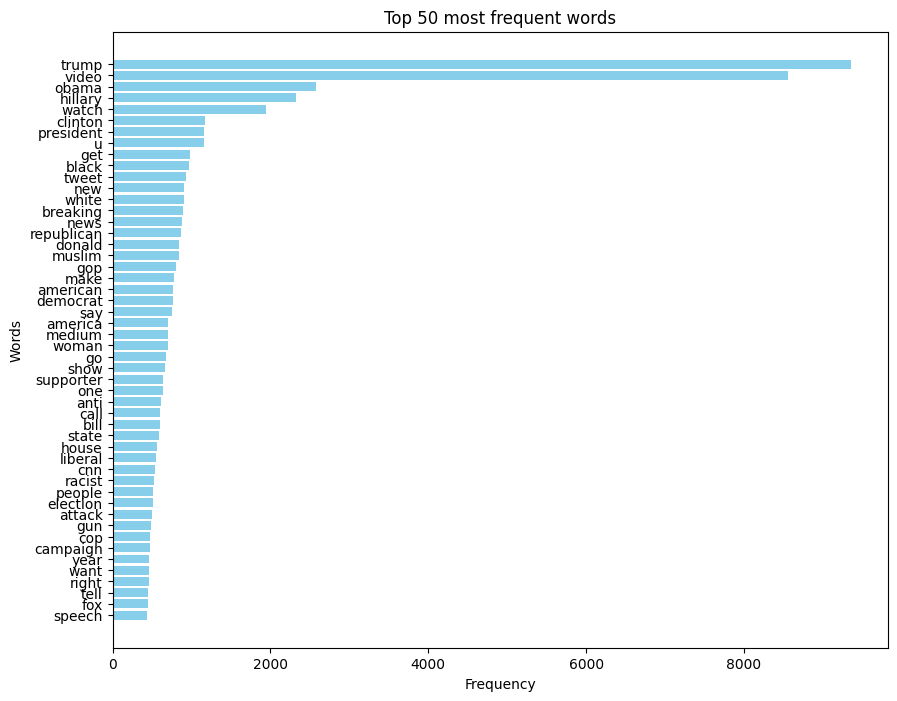

In [25]:
# Plot the frequency distribution of the 50 most common words in the dataset
plot_top_n_words_frequency(words_count_data_title_fake, "Word", "Count", 50)

In [26]:
def plot_word_frequency_distribution(data, count_column):
    # Assuming 'data' has been sorted or needs no sorting
    plt.figure(figsize=(12, 6))
    plt.plot(data[count_column].values, linestyle='-', marker='o', color='b')
    plt.title('Frequency Distribution of All Words')
    plt.xlabel('Words (Index)')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

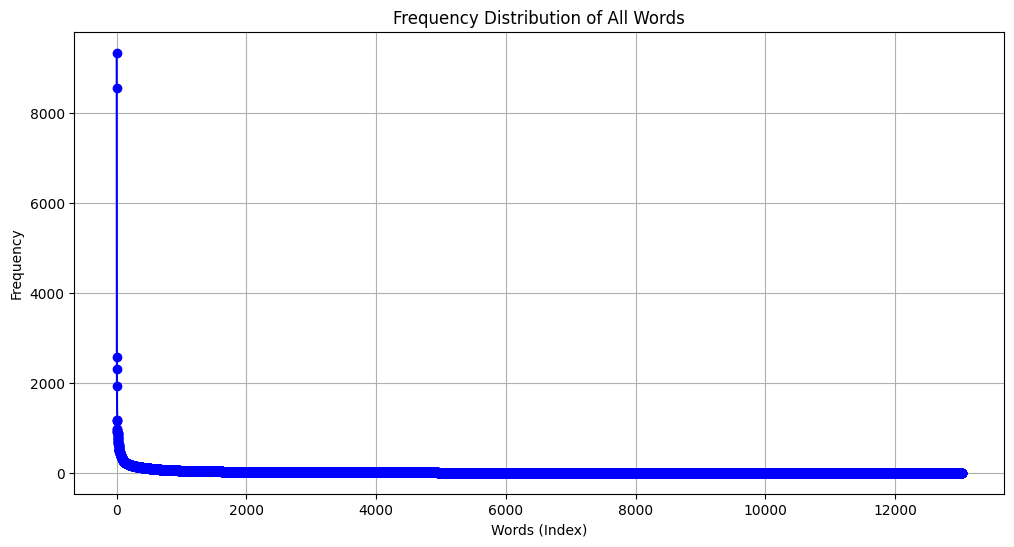

In [27]:
# Plot the frequency distribution of every word in the dataset
plot_word_frequency_distribution(words_count_data_title_fake, "Count")

*Para noticias verdaderas*

In [ ]:
# Get the number of occurrences of every word in the dataset
words_count_data_title_true = get_word_counts(df_clean[df_clean["output"] == "True"], "title")
words_count_data_title_true

,Word,Count
28,trump,5524
0,u,4690
43,say,3200
37,house,1450
4,republican,972
...,...,...
7285,vitriol,1
7284,disliked,1
7282,exception,1
7279,mug,1


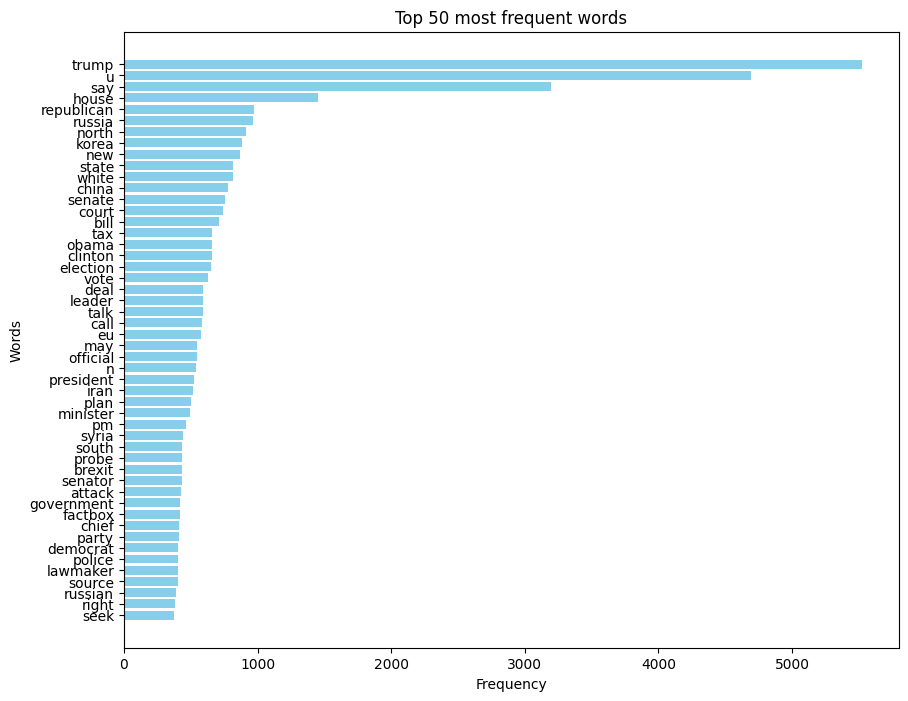

In [ ]:
# Plot the frequency distribution of the 50 most common words in the dataset
plot_top_n_words_frequency(words_count_data_title_true, "Word", "Count", 50)

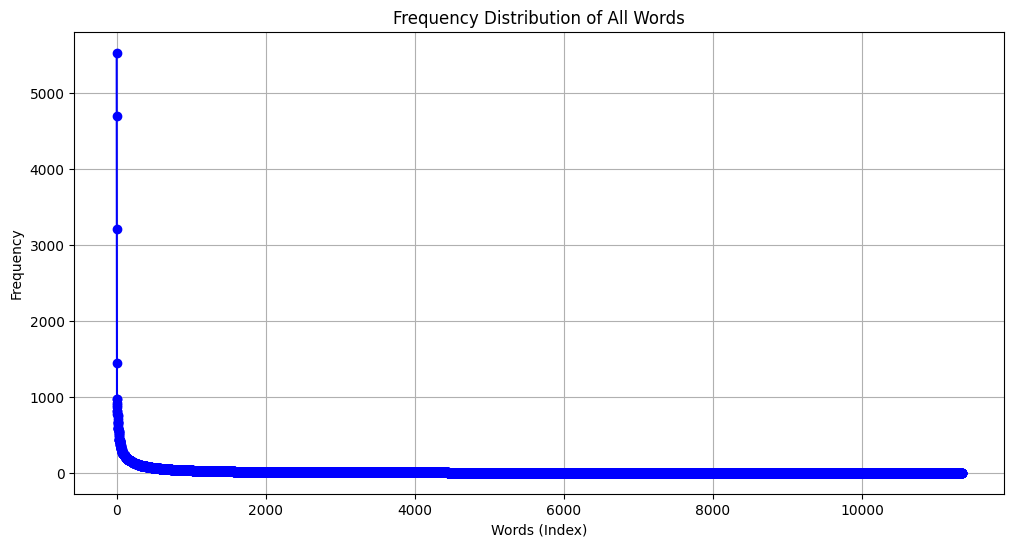

In [ ]:
# Plot the frequency distribution of every word in the dataset
plot_word_frequency_distribution(words_count_data_title_true, "Count")

## TFIDF

In [28]:
# Transform into TFIDF
corpus = df_clean['title'].tolist()
tfidf = TfidfVectorizer(norm='l2', use_idf=True, max_df=20, smooth_idf=False, stop_words=stop_words)
tfidf.fit_transform(corpus)

# Limit to the first 20 titles
for i, (text, data) in enumerate(df_clean.groupby('title')):
    if i >= 10: # modificar en función del número de resultados deseado
        break  # Exit the loop after processing 20 titles

    feat = np.sum(tfidf.transform(data['text']).toarray(), axis=0)
    sort_idx = np.argsort(feat.flatten())[::-1]  # Sort descending
    fav = [tfidf.get_feature_names_out()[idx] for idx in sort_idx.tolist()[:10]]
    print(title + "'s Fav words:")
    for w in fav:
        print('\t' + w)
    print()

 #WeAreNotThis: Twitter DESTROYS NC Gov. And GOP Over Sweeping Anti-LGBT Legislation (TWEETS)'s Fav words:
	aar
	dale
	logistics
	mln
	subsidiary
	inc
	landing
	performed
	management
	miami

 #WeAreNotThis: Twitter DESTROYS NC Gov. And GOP Over Sweeping Anti-LGBT Legislation (TWEETS)'s Fav words:
	animal
	zoo
	aardvark
	meerkat
	cafe
	nearby
	firefighter
	blaze
	spreading
	mammal

 #WeAreNotThis: Twitter DESTROYS NC Gov. And GOP Over Sweeping Anti-LGBT Legislation (TWEETS)'s Fav words:
	abadi
	paramilitary
	ite
	operated
	erbil
	alongside
	allied
	mosul
	tehran
	haider

 #WeAreNotThis: Twitter DESTROYS NC Gov. And GOP Over Sweeping Anti-LGBT Legislation (TWEETS)'s Fav words:
	krg
	abadi
	erbil
	autonomous
	regain
	secede
	haider
	appealed
	settling
	inclusive

 #WeAreNotThis: Twitter DESTROYS NC Gov. And GOP Over Sweeping Anti-LGBT Legislation (TWEETS)'s Fav words:
	marawi
	rubble
	nearby
	heavy
	returning
	returnees
	seller
	booby
	petrol
	flattened

 #WeAreNotThis: Twitter DESTROYS N

## Conteo de palabras

In [ ]:
# Print the number of different words in the dataset
print(f"Number of different words in the dataset: {len(words_count_data_title_fake)}")
# Create a table with the number of words with less than 10, 5, 3 and 2 occurrences
word_counts_aux = pd.DataFrame({"Count": [10, 5, 3, 2]})
word_counts_aux["number_of_words"] = (
    word_counts_aux["Count"]
    .apply(lambda x: len(words_count_data_title_fake[words_count_data_title_fake["Count"] < x]))
)
word_counts_aux

Number of different words in the dataset: 13033


,Count,number_of_words
0,10,9454
1,5,7543
2,3,5529
3,2,3109


In [ ]:
# Print the number of different words in the dataset
print(f"Number of different words in the dataset: {len(words_count_data_title_true)}")
# Create a table with the number of words with less than 10, 5, 3 and 2 occurrences
word_counts_aux = pd.DataFrame({"Count": [10, 5, 3, 2]})
word_counts_aux["number_of_words"] = (
    word_counts_aux["Count"]
    .apply(lambda x: len(words_count_data_title_true[words_count_data_title_true["Count"] < x]))
)
word_counts_aux

Number of different words in the dataset: 11346


,Count,number_of_words
0,10,8943
1,5,7504
2,3,5981
3,2,4315


In [ ]:
def filter_words_by_frequency(text, word_freq):
    # Split text into words
    words = text.split()
    # Filter words based on frequency in the word_freq dictionary
    filtered_words = [word for word in words if word_freq.get(word, 0) >= 5]  # Example: keep words with frequency >= 5
    # Join words back into a string
    return ' '.join(filtered_words)

# Create a dictionary with the words and their frequency for faster access
word_freq_fake = dict(zip(words_count_data_title_fake["Word"], words_count_data_title_fake["Count"]))

# Apply the filter_words_by_frequency function to the "headline" column
df_clean["title"] = df_clean["title"].apply(filter_words_by_frequency, args=(word_freq_fake,))

<ipython-input-40-174d263e7d2f>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["title"] = df_clean["title"].apply(filter_words_by_frequency, args=(word_freq_fake,))


In [ ]:
# Create a dictionary with the words and their frequency for faster access
word_freq_true = dict(zip(words_count_data_title_true["Word"], words_count_data_title_true["Count"]))

# Apply the filter_words_by_frequency function to the "headline" column
df_clean["title"] = df_clean["title"].apply(filter_words_by_frequency, args=(word_freq_true,))

<ipython-input-41-70c1aaf52b3a>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["title"] = df_clean["title"].apply(filter_words_by_frequency, args=(word_freq_true,))


In [ ]:
# Get the length of every headline
df_clean["length"] = df_clean["title"].apply(lambda x: len(x.split()))
df_clean.head()

<ipython-input-42-b764bc4a9b0b>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["length"] = df_clean["title"].apply(lambda x: len(x.split()))


,title,text,subject,date,output,length
0,u budget fight republican,washington reuters head conservative republica...,politicsNews,"December 31, 2017",True,4
1,u military accept transgender recruit monday p...,washington reuters transgender people allowed ...,politicsNews,"December 29, 2017",True,7
2,senior u republican senator let mueller job,washington reuters special counsel investigati...,politicsNews,"December 31, 2017",True,7
3,fbi russia probe helped australian diplomat ti...,washington reuters trump campaign adviser geor...,politicsNews,"December 30, 2017",True,8
4,trump want service charge much amazon shipment,seattle washington reuters president donald tr...,politicsNews,"December 29, 2017",True,7


In [ ]:
# Get the headlines with length 2 or less
short_headlines = df_clean[df_clean["title"].apply(lambda x: len(x.split()) <= 2)]["title"].unique()
print(f'There are {len(short_headlines)} headlines with length 5 or less.')
# Drop them
data = df_clean[~df_clean["title"].isin(short_headlines)]

There are 413 headlines with length 5 or less.


## Word Cloud

*Para notificas Fake*

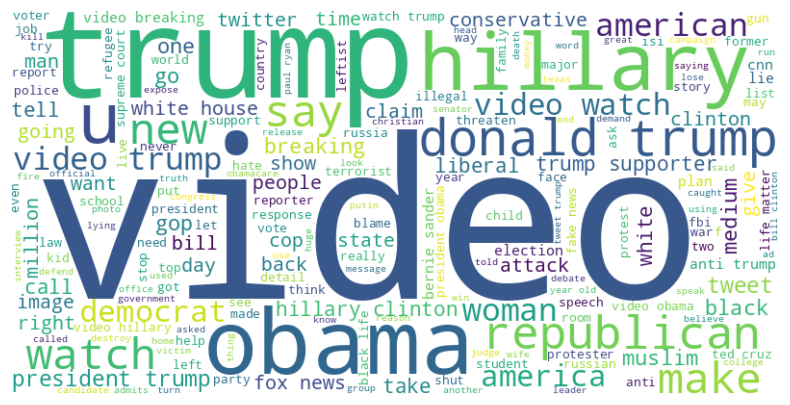

In [ ]:
def plot_wordcloud(data, column):
    # Join all the text in the column into a single string
    text = ' '.join(data[column].dropna())
    # Create the word cloud object, set the size and background color
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    # Display the word cloud using matplotlib
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')  # Turn off the axis
    plt.show()

plot_wordcloud(df_clean[df_clean['output']=='Fake'], "title")

*Para noticias reales*

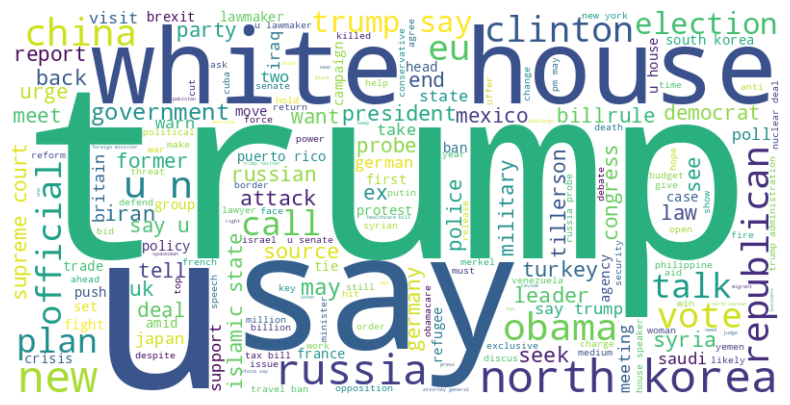

In [ ]:
plot_wordcloud(df_clean[df_clean['output']=='True'], "title")